In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
w_data=data['winterp']#.data
qcqi_data=(data['qc']+data['qi'])#.data

In [ ]:
####################################
#AREA FRACTION PLOTS

In [25]:
w_thresh1=0.1
w_thresh2=0.5
w_thresh3=1
qcqi_thresh1=1e-6
qcqi_thresh2=1e-6

In [26]:

where1=np.where((w_data>=w_thresh1)&(qcqi_data<qcqi_thresh2))
where2=np.where((w_data>=w_thresh2)&(qcqi_data<qcqi_thresh2))
where3=np.where((w_data>=w_thresh3)&(qcqi_data<qcqi_thresh2))
where4=np.where((w_data>=w_thresh1) & (qcqi_data>=qcqi_thresh1))
where5=np.where((w_data>=w_thresh2) & (qcqi_data>=qcqi_thresh1))
where6=np.where((w_data>=w_thresh3) & (qcqi_data>=qcqi_thresh1))

In [27]:
Lx=(data['xf'][-1]-data['xf'][0]).values #km
Ly=(data['yf'][-1]-data['yf'][0]).values #km
Area=Lx*Ly

profile1=np.bincount(where1[1])/Area#/np.diff(data['zf'])
profile2=np.bincount(where2[1])/Area#/np.diff(data['zf'])
profile3=np.bincount(where3[1])/Area#/np.diff(data['zf'])
profile4=np.bincount(where4[1])/Area#/np.diff(data['zf'])
profile5=np.bincount(where5[1])/Area#/np.diff(data['zf'])
profile6=np.bincount(where6[1])/Area#/np.diff(data['zf'])

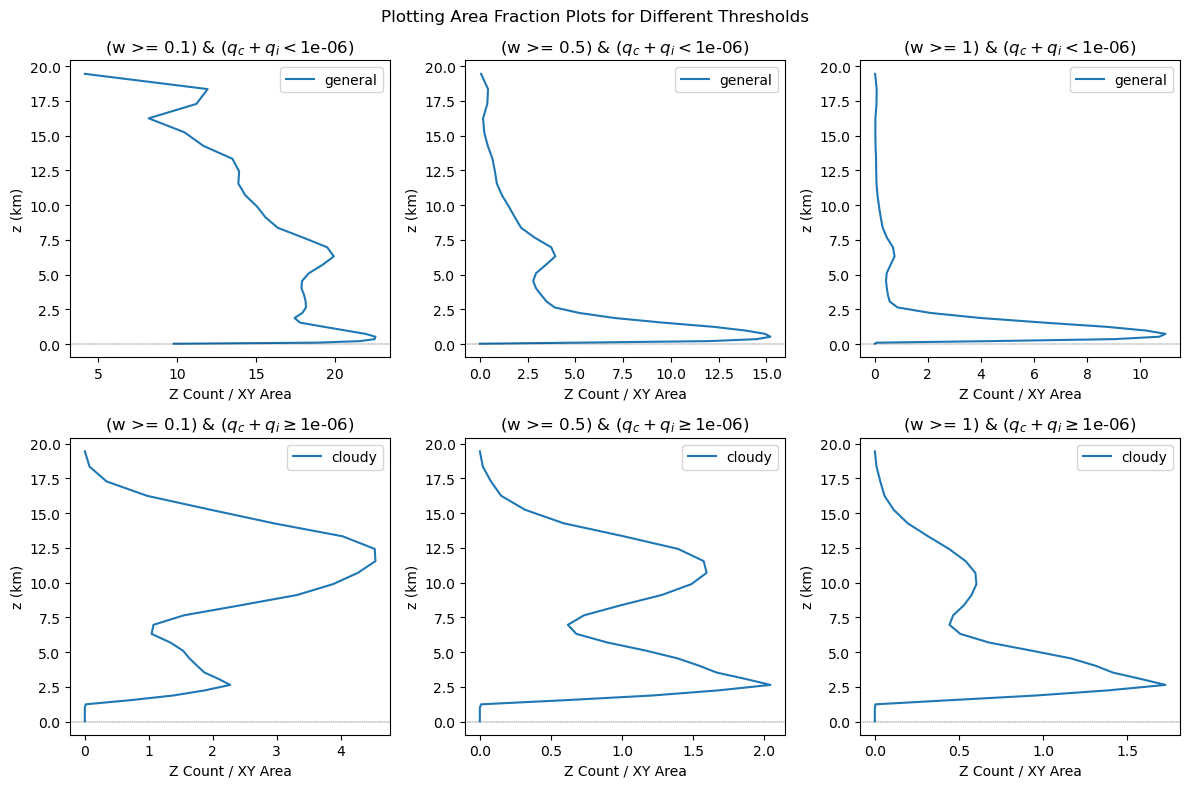

In [28]:
profiles=[profile1,profile2,profile3,profile4,profile5,profile6]
titles = [
    f'(w >= {w_thresh1}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh2})', 
    f'(w >= {w_thresh2}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh2})', 
    f'(w >= {w_thresh3}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh2})',
    f'(w >= {w_thresh1}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh1})',
    f'(w >= {w_thresh2}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh1})',
    f'(w >= {w_thresh3}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh1})'
]

labels=['general','general','general','cloudy','cloudy','cloudy']
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Create subplots for each profile
axes = []
for i in range(6):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.plot(profiles[i], data['zh'],label=labels[i])
    ax.set_title(titles[i])
    ax.set_xlabel('Z Count / XY Area')
    ax.set_ylabel('z (km)')
    ax.legend()
    axes.append(ax)
    ax.axhline(color='k',linestyle='dashed',linewidth=0.3)
    

fig.suptitle('Plotting Area Fraction Plots for Different Thresholds')

fig.tight_layout()

In [ ]:
#TESTING General Updrafts with smaller qc+qi threshold
################################################################

In [12]:
w_thresh1=0.1
w_thresh2=0.5
w_thresh3=1
qcqi_thresh1=1e-6
qcqi_thresh2=1e-11

In [18]:

where1=np.where((w_data>=w_thresh1)&(qcqi_data<qcqi_thresh2))
where2=np.where((w_data>=w_thresh2)&(qcqi_data<qcqi_thresh2))
where3=np.where((w_data>=w_thresh3)&(qcqi_data<qcqi_thresh2))
where4=np.where((w_data>=w_thresh1) & (qcqi_data>=qcqi_thresh1))
where5=np.where((w_data>=w_thresh2) & (qcqi_data>=qcqi_thresh1))
where6=np.where((w_data>=w_thresh3) & (qcqi_data>=qcqi_thresh1))

In [21]:
Lx=(data['xf'][-1]-data['xf'][0]).values #km
Ly=(data['yf'][-1]-data['yf'][0]).values #km
Area=Lx*Ly

profile1=np.bincount(where1[1])/Area#/np.diff(data['zf'])
profile2=np.bincount(where2[1])/Area#/np.diff(data['zf'])
profile3=np.bincount(where3[1])/Area#/np.diff(data['zf'])
profile4=np.bincount(where4[1])/Area#/np.diff(data['zf'])
profile5=np.bincount(where5[1])/Area#/np.diff(data['zf'])
profile6=np.bincount(where6[1])/Area#/np.diff(data['zf'])

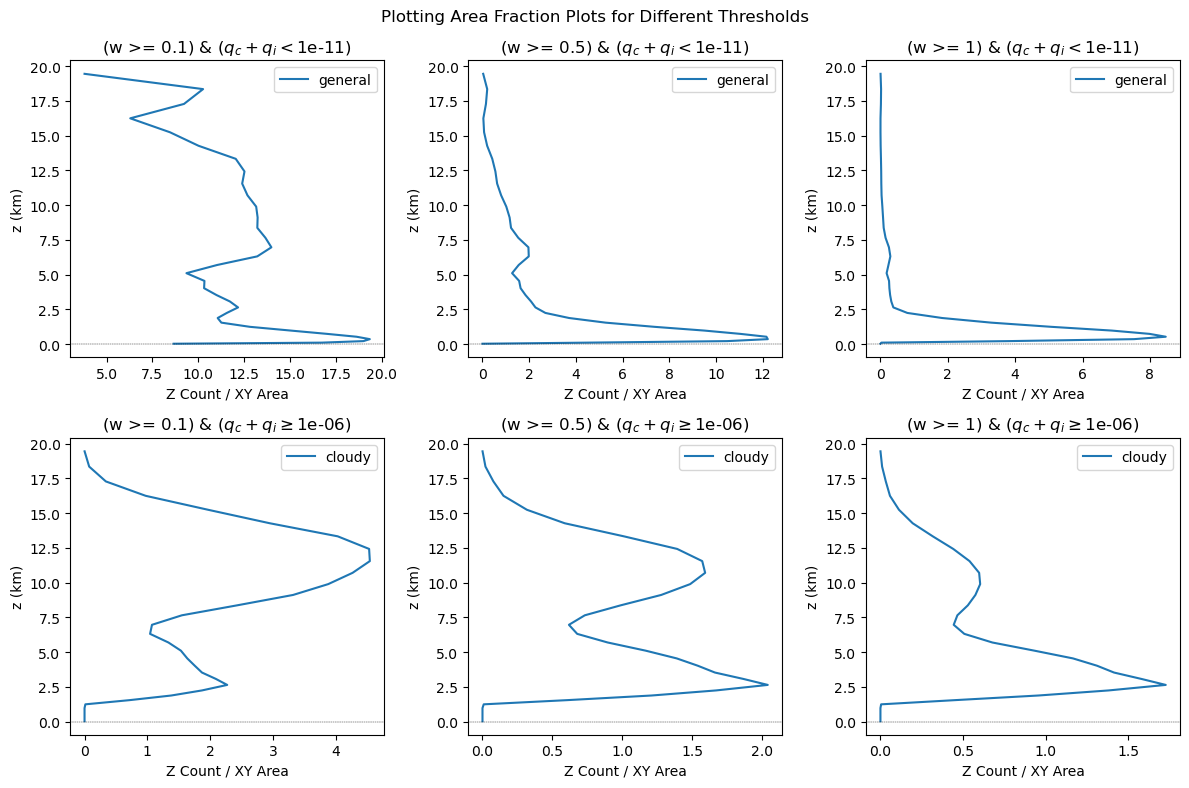

In [22]:
profiles=[profile1,profile2,profile3,profile4,profile5,profile6]
titles = [
    f'(w >= {w_thresh1}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh2})', 
    f'(w >= {w_thresh2}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh2})', 
    f'(w >= {w_thresh3}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh2})',
    f'(w >= {w_thresh1}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh1})',
    f'(w >= {w_thresh2}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh1})',
    f'(w >= {w_thresh3}) & (' + r'$q_c + q_i \geq $' + f'{qcqi_thresh1})'
]

labels=['general','general','general','cloudy','cloudy','cloudy']
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Create subplots for each profile
axes = []
for i in range(6):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.plot(profiles[i], data['zh'],label=labels[i])
    ax.set_title(titles[i])
    ax.set_xlabel('Z Count / XY Area')
    ax.set_ylabel('z (km)')
    ax.legend()
    axes.append(ax)
    ax.axhline(color='k',linestyle='dashed',linewidth=0.3)
    

fig.suptitle('Plotting Area Fraction Plots for Different Thresholds')

fig.tight_layout()

In [16]:
w_thresh1=0.1
w_thresh2=0.2
w_thresh3=0.3
w_thresh4=0.4
w_thresh5=0.5
qcqi_thresh1=1e-6

In [17]:
where1=np.where((w_data>=w_thresh1) & (qcqi_data<qcqi_thresh1))
where2=np.where((w_data>=w_thresh2) & (qcqi_data<qcqi_thresh1))
where3=np.where((w_data>=w_thresh3) & (qcqi_data<qcqi_thresh1))
where4=np.where((w_data>=w_thresh4) & (qcqi_data<qcqi_thresh1))
where5=np.where((w_data>=w_thresh5) & (qcqi_data<qcqi_thresh1))

In [18]:
Lx=(data['xf'][-1]-data['xf'][0]).values #km
Ly=(data['yf'][-1]-data['yf'][0]).values #km
Area=Lx*Ly

profile1=np.bincount(where1[1])/Area#/np.diff(data['zf'])
profile2=np.bincount(where2[1])/Area#/np.diff(data['zf'])
profile3=np.bincount(where3[1])/Area#/np.diff(data['zf'])
profile4=np.bincount(where4[1])/Area#/np.diff(data['zf'])
profile5=np.bincount(where5[1])/Area#/np.diff(data['zf'])

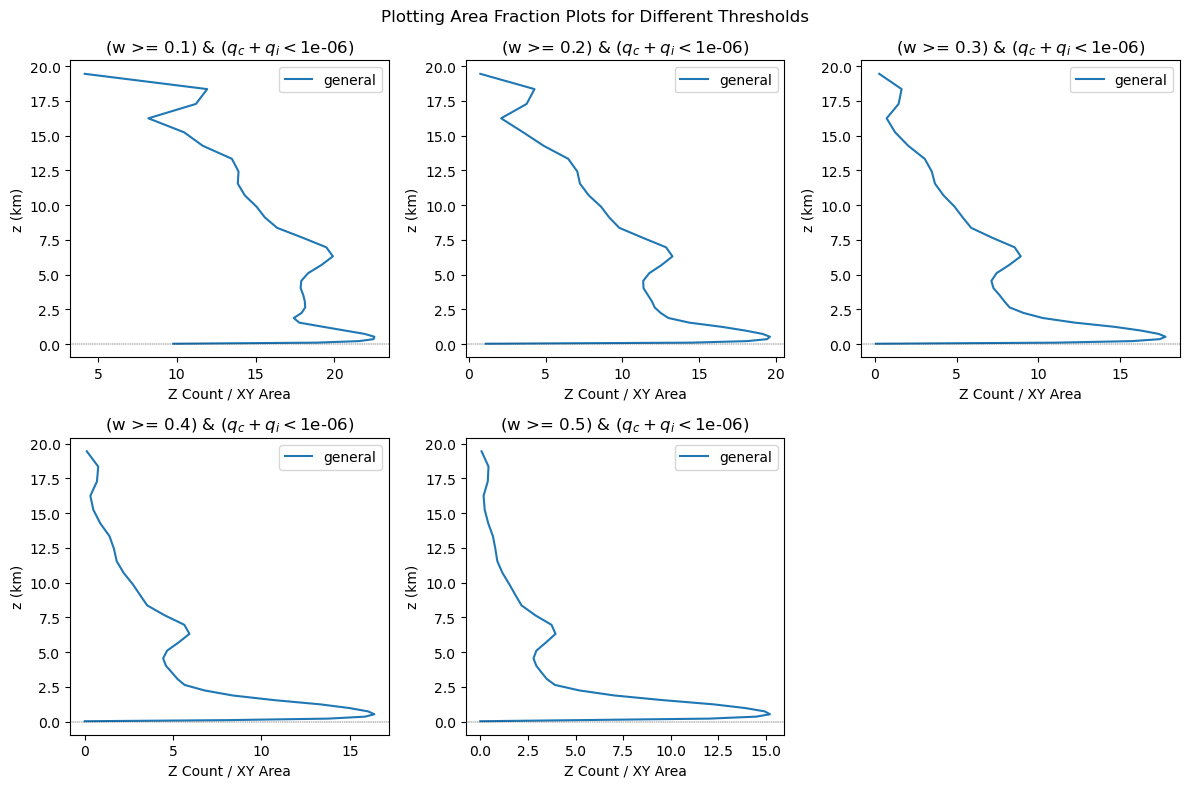

In [19]:
profiles=[profile1,profile2,profile3,profile4,profile5]
titles = [
    f'(w >= {w_thresh1}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh1})', 
    f'(w >= {w_thresh2}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh1})', 
    f'(w >= {w_thresh3}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh1})',
    f'(w >= {w_thresh4}) & (' + r'$q_c + q_i < $' + f'{qcqi_thresh1})',
    f'(w >= {w_thresh5}) & (' + r'$q_c + q_i < $' + f'{qcqi_thresh1})'
]

labels=['general','general','general','general','general']
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Create subplots for each profile
axes = []
for i in range(5):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.plot(profiles[i], data['zh'],label=labels[i])
    ax.set_title(titles[i])
    ax.set_xlabel('Z Count / XY Area')
    ax.set_ylabel('z (km)')
    ax.legend()
    axes.append(ax)
    ax.axhline(color='k',linestyle='dashed',linewidth=0.3)
    

fig.suptitle('Plotting Area Fraction Plots for Different Thresholds')

fig.tight_layout()

In [29]:
############################################################################
#CONTOUR PLOTS

In [30]:
# w_thresh1=0.1
# w_thresh2=0.5
# w_thresh3=1
# qcqi_thresh=1e-6

In [31]:
# #General Updrafts
# w_data1=np.where((w_data>=w_thresh1)&(qcqi_data<qcqi_thresh), w_data, np.nan)
# w_data2=np.where((w_data>=w_thresh2)&(qcqi_data<qcqi_thresh), w_data, np.nan)
# w_data3=np.where((w_data>=w_thresh3)&(qcqi_data<qcqi_thresh), w_data, np.nan)

# w_data_mean1=np.nanmean(w_data1,axis=(2,3)).T
# w_data_mean2=np.nanmean(w_data2,axis=(2,3)).T
# w_data_mean3=np.nanmean(w_data3,axis=(2,3)).T

In [32]:
# w_data4=np.where((w_data>=w_thresh1) & (qcqi_data>=qcqi_thresh), w_data, np.nan)
# w_data5=np.where((w_data>=w_thresh2) & (qcqi_data>=qcqi_thresh), w_data, np.nan)
# w_data6=np.where((w_data>=w_thresh3) & (qcqi_data>=qcqi_thresh), w_data, np.nan)

# w_data_mean4=np.nanmean(w_data4,axis=(2,3)).T
# w_data_mean5=np.nanmean(w_data5,axis=(2,3)).T
# w_data_mean6=np.nanmean(w_data6,axis=(2,3)).T

In [ ]:
# fig = plt.figure(figsize=(15, 8))
# gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# # First subplot
# ax1 = fig.add_subplot(gs[0, 0])
# c1 = ax1.contourf(w_data_mean1)
# fig.colorbar(c1, ax=ax1)
# ax1.set_title(f'(w >= {w_thresh1}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh})')

# # Second subplot
# ax2 = fig.add_subplot(gs[0, 1])
# c2 = ax2.contourf(w_data_mean2)
# fig.colorbar(c2, ax=ax2)
# ax2.set_title(f'(w >= {w_thresh2}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh})')

# # Third subplot
# ax3 = fig.add_subplot(gs[0, 2])
# c3 = ax3.contourf(w_data_mean3)
# fig.colorbar(c3, ax=ax3)
# ax3.set_title(f'(w >= {w_thresh3}) & (' + r'$q_c+q_i < $' + f'{qcqi_thresh})')

# #########################################


# # First subplot
# ax4 = fig.add_subplot(gs[1, 0])
# c4 = ax4.contourf(w_data_mean4)
# fig.colorbar(c4, ax=ax4)
# ax4.set_title(f'(w >= {w_thresh1}) & (' + r'$q_c+q_i >= $' + f'{qcqi_thresh})')

# # Second subplot
# ax5 = fig.add_subplot(gs[1, 1])
# c5 = ax5.contourf(w_data_mean5)
# fig.colorbar(c5, ax=ax5)
# ax5.set_title(f'(w >= {w_thresh2}) & (' + r'$q_c+q_i >= $' + f'{qcqi_thresh})')

# # Third subplot
# ax6 = fig.add_subplot(gs[1, 2])
# c6 = ax6.contourf(w_data_mean6)
# fig.colorbar(c6, ax=ax6)
# ax6.set_title(f'(w >= {w_thresh3}) & (' + r'$q_c+q_i >= $' + f'{qcqi_thresh})')


# #SETTING X AND Y LABELS
# for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
#     axis.set_xlabel('t (mins)')
#     axis.set_ylabel('z (kms)')


# #FIXING HEIGHT LABELS
# axises=[ax1, ax2, ax3, ax4, ax5, ax6]
# x_space_labels(axises,type='t')
# y_space_labels(axises)
      

# fig.suptitle('Plotting (z,t) W mean For Different Thresholds')